In [30]:
import pandas as pd
import re
import spacy
from IPython.display import YouTubeVideo

In [3]:
with open(file = 'Avatar_S3_E21_Transcript.txt', mode = 'r', encoding = 'utf-8') as file:
    transcript = file.read() 

In [4]:
rows = []

# For each line in the transcript, strip() removes extra whitespace/newlines at the start & end. 
# split("\n") separates the text into individual lines
for line in transcript.strip().split("\n"):

    # Split the line into two parts using 2 or more spaces as the separator. r"\s{2,}" means any whitespace character occurring 2 or more times.
    # maxsplit=1 ensures the line is only split once
    parts = re.split(r"\s{2,}", line, maxsplit=1)
    
    if len(parts) == 2:
        character = parts[0]

        # Remove bracketed text (non-dialogue) from dialogue
        dialogue = re.sub(r"\[.*?\]", "", parts[1])

        # Clean up extra whitespace
        dialogue = re.sub(r"\s+", " ", dialogue).strip()

        rows.append([character, dialogue])

transcript_df = pd.DataFrame(rows, columns=["Character", "Dialogue"])

In [5]:
# Save the dataframe
transcript_df.to_pickle('transcript_df.pkl')

In [6]:
transcript_df = pd.read_pickle('transcript_df.pkl')

<Axes: title={'center': 'Frequency Of Character Dialogue'}, xlabel='Character', ylabel='Frequency'>

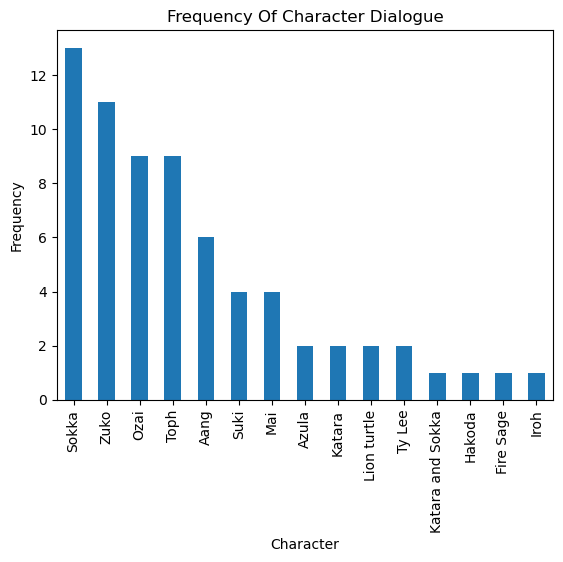

In [11]:
# Plot a bar graph
transcript_df["Character"].value_counts().plot(kind = "bar", title = "Frequency Of Character Dialogue", ylabel = "Frequency")

Funnily enough, Aang isn't even in the top three even though it's the series finale 😆

In [13]:
nlp = spacy.load("en_core_web_sm")

In [15]:
# Create a new column called Dialogue Doc, which is then passed through the spacy pipeline for analysis.
transcript_df["Dialogue Doc"] = transcript_df["Dialogue"].apply(nlp)

# Add token count column
transcript_df["Token Count"] = transcript_df["Dialogue Doc"].apply(len)

In [16]:
transcript_df

,Character,Dialogue,Dialogue Doc,Token Count
0,Ozai,"Come on out, Avatar! You can't hide in there f...","(Come, on, out, ,, Avatar, !, You, ca, n't, hi...",14
1,Sokka,"Toph, metalbend the rudder so it's jammed in a...","(Toph, ,, metalbend, the, rudder, so, it, 's, ...",24
2,Toph,Got it!,"(Got, it, !)",3
3,Sokka,Have I ever mentioned how sweet it is that you...,"(Have, I, ever, mentioned, how, sweet, it, is,...",13
4,Toph,You could stand to mention it more.,"(You, could, stand, to, mention, it, more, .)",8
...,...,...,...,...
63,Mai,I look like a man.,"(I, look, like, a, man, .)",6
64,Suki,And why did you paint me firebending?,"(And, why, did, you, paint, me, firebending, ?)",8
65,Sokka,I thought it looked more exciting that way. Oh...,"(I, thought, it, looked, more, exciting, that,...",22
66,Iroh,"Hey, my belly's not that big anymore. I've rea...","(Hey, ,, my, belly, 's, not, that, big, anymor...",16


In [17]:
# Get the top three speakers -> Get the labels (which are the index of the series) -> Convert to a list
top_speakers = (
    transcript_df["Character"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

In [18]:
# Filter by the top three speakers
top_speaker_df = transcript_df[transcript_df["Character"].isin(top_speakers)]

In [19]:
# Pick the longest dialogue for each top speaker
top_speaker_df = top_speaker_df.sort_values("Token Count", ascending=False).drop_duplicates("Character")

In [20]:
top_speaker_df

,Character,Dialogue,Dialogue Doc,Token Count
51,Zuko,Please. The real hero is the Avatar. Today thi...,"(Please, ., The, real, hero, is, the, Avatar, ...",82
41,Sokka,"There's my favorite warriors! I have to admit,...","(There, 's, my, favorite, warriors, !, I, have...",30
53,Ozai,I should count myself lucky. The new Fire Lord...,"(I, should, count, myself, lucky, ., The, new,...",22


In [27]:
# Tokens & morphology of each top speaker's longest dialogue.

# iterrows() return the row index & the row data.
# The loop receives these two values each time, but the underscore means that the first value (row index) is ignored.
for _, row in top_speaker_df.iterrows():

    print(f"\nCharacter: {row["Character"]}")

    for token in row["Dialogue Doc"]:
        
        # Skip punctuation mark tokens
        if token.is_punct == True:
            pass
        else:
            
            # Print tokens + morphology
            print(
                f"Token: {token.text:<15} "
                f"Morphology: {token.morph}"
            )


Character: Zuko
Token: Please          Morphology: 
Token: The             Morphology: Definite=Def|PronType=Art
Token: real            Morphology: Degree=Pos
Token: hero            Morphology: Number=Sing
Token: is              Morphology: Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
Token: the             Morphology: Definite=Def|PronType=Art
Token: Avatar          Morphology: Number=Sing
Token: Today           Morphology: Number=Sing
Token: this            Morphology: Number=Sing|PronType=Dem
Token: war             Morphology: Number=Sing
Token: is              Morphology: Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
Token: finally         Morphology: 
Token: over            Morphology: 
Token: I               Morphology: Case=Nom|Number=Sing|Person=1|PronType=Prs
Token: promised        Morphology: Tense=Past|VerbForm=Fin
Token: my              Morphology: Number=Sing|Person=1|Poss=Yes|PronType=Prs
Token: uncle           Morphology: Number=Sing
Token: that        

In [28]:
# Named Entity Recognition of each top speaker's longest dialogue
for _, row in top_speaker_df.iterrows():
    
    print(f"\n{row["Character"]} mentioned these named entities:")

    if not row["Dialogue Doc"].ents:
            print("None")
    else:
        for ent in row["Dialogue Doc"].ents:
    
        # Print named entites & their labels
            print(
                f"{ent.text:<15} "
                f"Label/Type: {ent.label_}"
            )


Zuko mentioned these named entities:
Avatar          Label/Type: ORG
Today           Label/Type: DATE
the Fire Nation Label/Type: ORG
A hundred years Label/Type: DATE
Avatar          Label/Type: ORG

Sokka mentioned these named entities:
None

Ozai mentioned these named entities:
Fire Lord       Label/Type: PERSON


It might seem weird that Sokka has not mentioned any named entities, but if we run the cell below, we can see that is indeed the case.

In [29]:
for _, row in top_speaker_df.iterrows():
    print(f"{row["Character"]}")
    print(f"{row["Dialogue"]}\n")

Zuko
Please. The real hero is the Avatar. Today this war is finally over! I promised my uncle that I would restore the honor of the Fire Nation. And I will. The road ahead of us is challenging. A hundred years of fighting has left the world scarred and divided. But with the Avatar's help, we can get it back on the right path and begin a new era of love and peace.

Sokka
There's my favorite warriors! I have to admit, I kind of missed the face paint. So how does it feel to be in uniform again?

Ozai
I should count myself lucky. The new Fire Lord has graced me with his presence in my lowly prison cell.



In [ ]:
# Enjoy this video of the season finale 🔥
YouTubeVideo('kXShLPXfWZA', height = 480, width = 854, start = 390)